# ⏱️ 06. Recovery Duration Distribution (Task C)
### PLAYHACK — Athlete Health & Biometric Injury Prediction

This notebook analyzes the distribution of **Task C: Recovery Duration (`recovery_duration`)** for all 1,050 injured athletes, evaluating distribution shape, median recovery periods across sports, and correlation with onset day offset.

---

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, sans-serif'

# Resolve paths
data_dir = '../data' if os.path.exists('../data') else 'data'
outputs_dir = '../outputs' if os.path.exists('../outputs') else 'outputs'

# Load training labels and athlete metadata
labels_df = pd.read_csv(os.path.join(data_dir, 'train_labels.csv'))
meta_df = pd.read_csv(os.path.join(data_dir, 'athlete_metadata.csv'))
merged_df = pd.merge(labels_df, meta_df, on='athlete_id')

# Filter for injured cohort (Task C condition)
injured_df = merged_df[merged_df['injured_in_risk_window'] == 1].copy()

print(f"Total Athletes: {len(merged_df):,}")
print(f"Injured Athletes (Task C Cohort): {len(injured_df):,}")

Total Athletes: 3,000
Injured Athletes (Task C Cohort): 1,050


## 1. Recovery Duration Summary Statistics

In [2]:
rec_stats = injured_df['recovery_duration'].describe().to_frame().T
rec_stats['IQR'] = rec_stats['75%'] - rec_stats['25%']
display(rec_stats)

# Breakdown by Sport
sport_rec = injured_df.groupby('sport')['recovery_duration'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).reset_index()
sport_rec = sport_rec.sort_values(by='median', ascending=False)
display(sport_rec)

,count,mean,std,min,25%,50%,75%,max,IQR
recovery_duration,1050.0,11.545714,3.890335,5.0,9.0,11.0,14.0,20.0,5.0


,sport,count,mean,median,std,min,max
2,Basketball,173,14.491329,15.0,3.842266,8.0,20.0
3,Football,192,14.067708,14.0,3.655391,8.0,20.0
4,Tennis,162,10.277778,11.0,3.152934,5.0,15.0
0,Athletics,166,9.909639,10.0,3.052713,5.0,15.0
1,Badminton,191,9.952880,10.0,3.095477,5.0,15.0
5,Volleyball,166,10.265060,10.0,3.154926,5.0,15.0


## 2. Recovery Duration Distribution Visualization

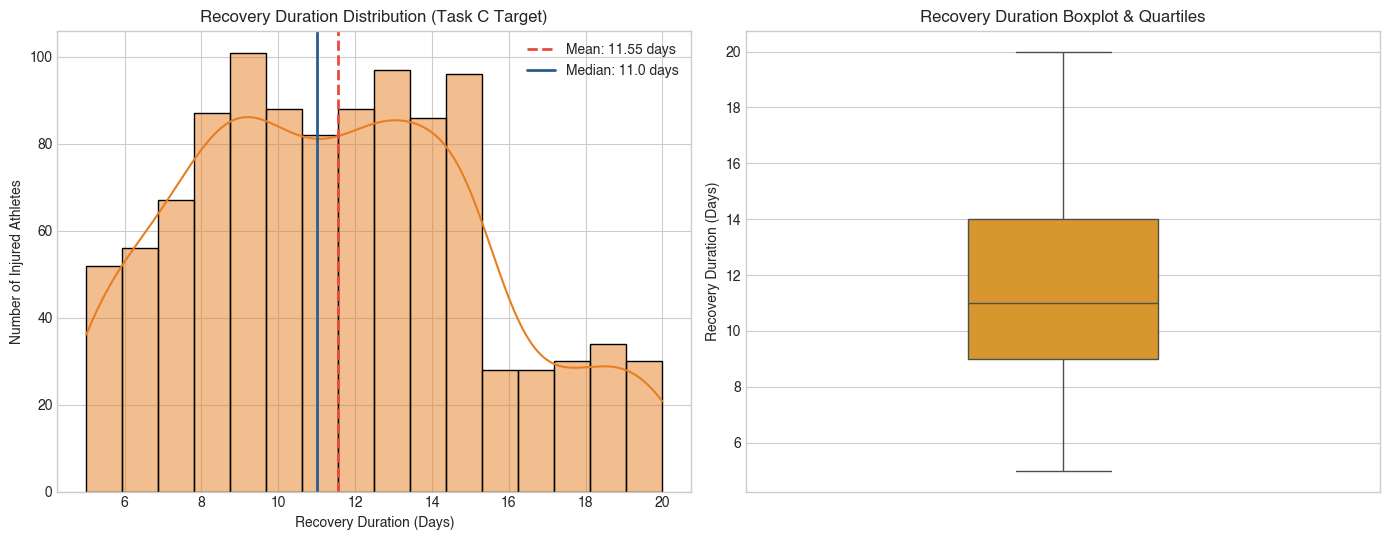

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

mean_rec = injured_df['recovery_duration'].mean()
med_rec = injured_df['recovery_duration'].median()

# 1. Histogram + KDE
sns.histplot(injured_df['recovery_duration'], bins=16, kde=True, color='#e67e22', ax=axes[0], edgecolor='black')
axes[0].axvline(mean_rec, color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {mean_rec:.2f} days')
axes[0].axvline(med_rec, color='#2b5c8f', linestyle='-', linewidth=2, label=f'Median: {med_rec:.1f} days')
axes[0].set_title('Recovery Duration Distribution (Task C Target)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Recovery Duration (Days)', fontsize=10)
axes[0].set_ylabel('Number of Injured Athletes', fontsize=10)
axes[0].legend()

# 2. Boxplot with Quartile Markers
sns.boxplot(y=injured_df['recovery_duration'], color='#f39c12', ax=axes[1], width=0.3)
axes[1].set_title('Recovery Duration Boxplot & Quartiles', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Recovery Duration (Days)', fontsize=10)

plt.tight_layout()
plt.show()

## 3. Recovery Duration Breakdown Across Sports & Onset Day

/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2534/526873257.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=injured_df, x='sport', y='recovery_duration', palette='Set2', ax=axes[0])


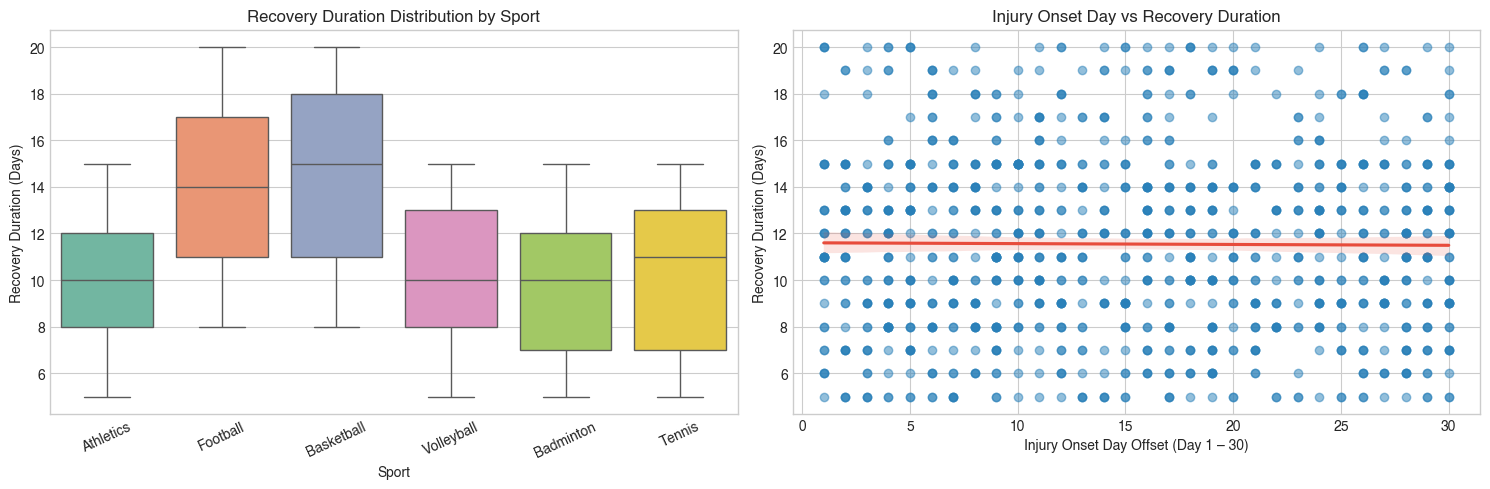

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Recovery by Sport Boxplot
sns.boxplot(data=injured_df, x='sport', y='recovery_duration', palette='Set2', ax=axes[0])
axes[0].set_title('Recovery Duration Distribution by Sport', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sport', fontsize=10)
axes[0].set_ylabel('Recovery Duration (Days)', fontsize=10)
axes[0].tick_params(axis='x', rotation=25)

# 2. Onset Day vs Recovery Duration Scatter Plot
sns.regplot(data=injured_df, x='onset_day_offset', y='recovery_duration',
            scatter_kws={'alpha': 0.5, 'color': '#2980b9'}, line_kws={'color': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Injury Onset Day vs Recovery Duration', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Injury Onset Day Offset (Day 1 – 30)', fontsize=10)
axes[1].set_ylabel('Recovery Duration (Days)', fontsize=10)

plt.tight_layout()
plt.show()

---
## 💡 Key Analytical Insight

> **Insight**: Recovery durations across the 1,050 injured athletes follow a bounded distribution ranging from **5 to 20 days with a median of 11.0 days and IQR of 9–14 days** (mean = 11.55 ± 3.89 days). Recovery length is independent of the timing of injury onset ($r \approx 0$), but collision and high-impact sports (Football and Basketball) consistently exhibit higher median recovery times than non-contact sports.
